### Imports necesarios

Se incluyen imports necesarios para el programa.

Numpy -> creacion del vector de tiempos

Matplotlib -> graficos

Scipy -> funciones de señales

Math -> funciones matematicas

In [103]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from math import sqrt

### Numero de muestras *N* y frecuencia de muestreo *fs*

Se crean las variables *N* (numero de muestras) y *fs* (frecuencia de muestreo). Se mantendran constantes en toda la simulacion.

In [104]:
N = 1000
fs = 1000

### Definicion de funciones

Se crean las funciones para generar señales. Cada funcion devuelve una tupla que contiene los vectores *xx* (vector de valores) y *tt* (vector de tiempos). Las funciones generadas (con los parametros por defecto) son de potencia de señal de 1W. Se considera R = 1 ohm (normalizada).


Para la señal senoidal:
$$P_{SEÑAL} = \frac{{V_{PICO}}^2}{2R}$$

Para la señal triangular/diente de sierra:
$$P_{SEÑAL} = \frac{{V_{PICO}}^2}{3R}$$

In [105]:
def pds_sen(nn = 1000, fs = 1000, freq = 1, Amax = sqrt(2), dc = 0, phase = 0):
    tt = np.arange(start = 0, step = 1/fs, stop = nn*(1/fs))
    xx = dc + Amax * np.sin(2*np.pi * freq * tt + phase)
    return xx, tt


def pds_triangular(nn = 1000, fs = 1000, freq = 1, Amax = sqrt(3), dc = 0, phase = 0):
    tt = np.arange(start = 0, step = 1/fs, stop = nn*(1/fs))
    xx = dc + Amax * signal.sawtooth(2*np.pi * freq * tt + phase, width = 0.5)
    return xx, tt

def pds_dientedesierra(nn = 1000, fs = 1000, freq = 1, Amax = sqrt(3), dc = 0, phase = 0, pendiente = 0.0):
    tt = np.arange(start = 0, step = 1/fs, stop = nn*(1/fs))
    xx = dc + Amax * signal.sawtooth(2*np.pi * freq * tt + phase, width = pendiente)
    return xx, tt

### Visualizacion señal senoidal

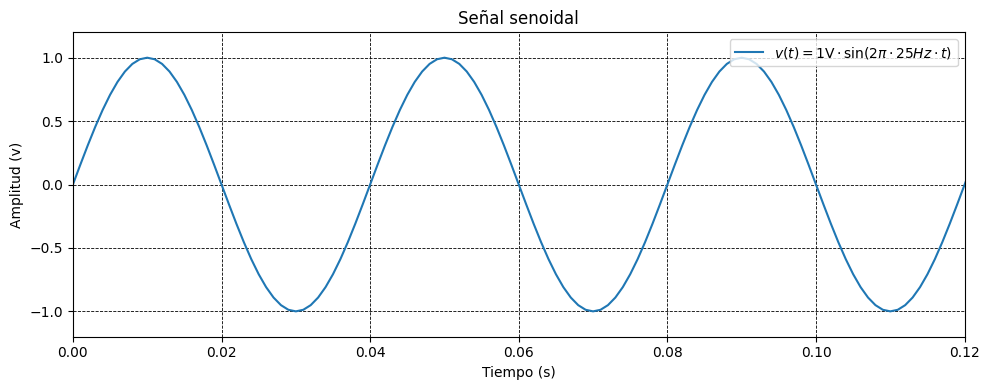

In [106]:
x1,tt = pds_sen(N, fs, Amax = 1, freq=25, dc = 0, phase = 0)

fig, ax = plt.subplots(figsize=(10, 4))

ax.grid(True, color="#000000FF", linewidth=0.6, linestyle="--")
ax.set_axisbelow(True)


ax.set_xlim(0, (1 / 25) * 3)
ax.set_ylim(-1.2, 1.2)

ax.plot(tt, x1, linewidth=1.5, label=r"$v(t) = 1\mathrm{V} \cdot \mathrm{sin}(2\pi \cdot 25Hz\cdot t)$")

ax.legend(loc="upper right", fontsize=10)
ax.set_title("Señal senoidal", fontsize=12)
ax.set_xlabel("Tiempo (s)", fontsize=10)
ax.set_ylabel("Amplitud (v)", fontsize=10)


plt.tight_layout()
plt.show()

Vemos que a 25 Hz, con 1000 muestras a 1000 muestras por segundo tenemos una visualizacion aceptable de la señal. 

Sin embargo, cuando queremos subir la frecuencia:

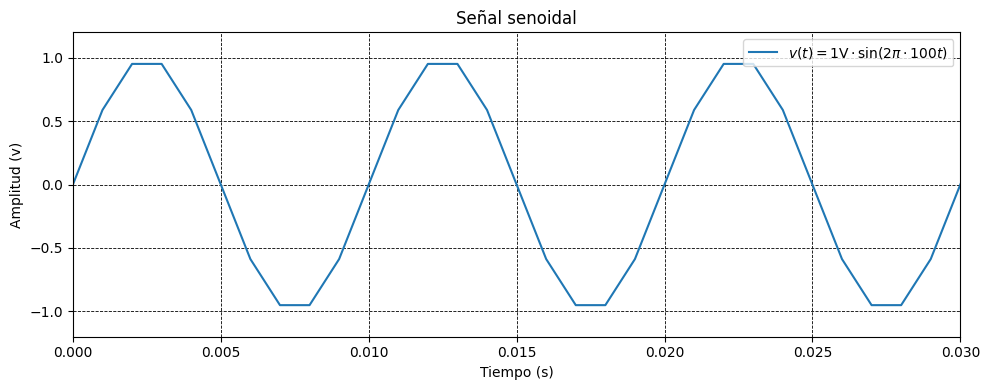

In [107]:
x1,tt = pds_sen(N, fs, Amax = 1, freq=100, dc = 0, phase = 0)

fig, ax = plt.subplots(figsize=(10, 4))

ax.grid(True, color="#000000FF", linewidth=0.6, linestyle="--")
ax.set_axisbelow(True)


ax.set_xlim(0, (1 / 100) * 3)
ax.set_ylim(-1.2, 1.2)

ax.plot(tt, x1, linewidth=1.5, label=r"$v(t) = 1\mathrm{V} \cdot \mathrm{sin}(2\pi \cdot 100t)$")

ax.legend(loc="upper right", fontsize=10)
ax.set_title("Señal senoidal", fontsize=12)
ax.set_xlabel("Tiempo (s)", fontsize=10)
ax.set_ylabel("Amplitud (v)", fontsize=10)


plt.tight_layout()
plt.show()

La interpolacion entre puntos de la señal ya no es una aproximacion aceptable para la visualizacion de la señal. Aunque se cumpla por bastante el teorema de Nyquist (fs = 10*ff) a simple vista podemos ver que la señal esta deformada.

De igual manera, tiene sentido que esto sea asi. Esa relacion entre la fs y ff nos da que solo tenemos 10 puntos de la señal por ciclo para la visualizacion. En el ejemplo anterior, con una ff de 25 Hz teniamos 40 puntos por ciclo de la señal.

### Visualizacion señal triangular

Señal triangular definida por:
$$
triangular(t) = \begin{cases} 
\frac{2}{T}t & 0 \leq t < \frac{T}{2} \\ 
-\frac{2}{T}t + 1 & \frac{T}{2} \leq t < T
\end{cases}
$$

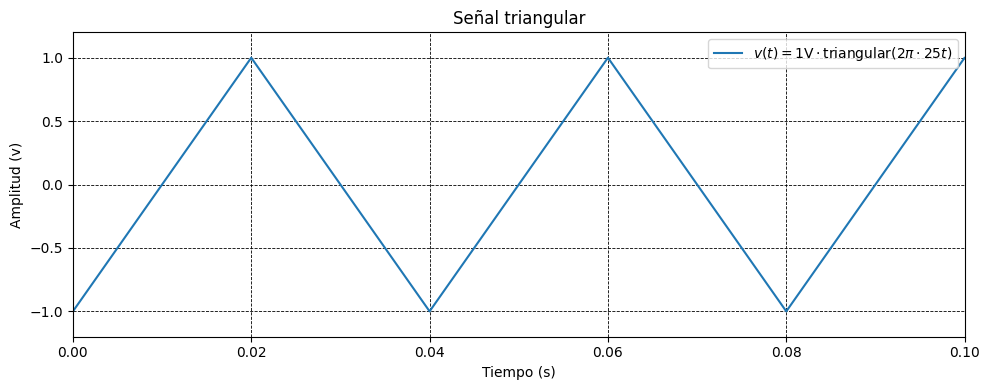

In [108]:
x1,tt = pds_triangular(N, fs, Amax = 1, freq=25, dc = 0, phase = 0)

fig, ax = plt.subplots(figsize=(10, 4))

ax.grid(True, color="#000000FF", linewidth=0.6, linestyle="--")
ax.set_axisbelow(True)


ax.set_xlim(0, (1 / 50) * 5)
ax.set_ylim(-1.2, 1.2)

ax.plot(tt, x1, linewidth=1.5, label=r"$v(t) = 1\mathrm{V} \cdot \mathrm{triangular}(2\pi \cdot 25t)$")

ax.legend(loc="upper right", fontsize=10)
ax.set_title("Señal triangular", fontsize=12)
ax.set_xlabel("Tiempo (s)", fontsize=10)
ax.set_ylabel("Amplitud (v)", fontsize=10)


plt.tight_layout()
plt.show()

### Visualizacion señal diente de sierra

Señal diente de sierra definida por:
$$
dds(t) = \begin{cases} 
-\frac{2}{T}t + 1 & 0 \leq t < T \\ 
1 & t = T
\end{cases}
$$

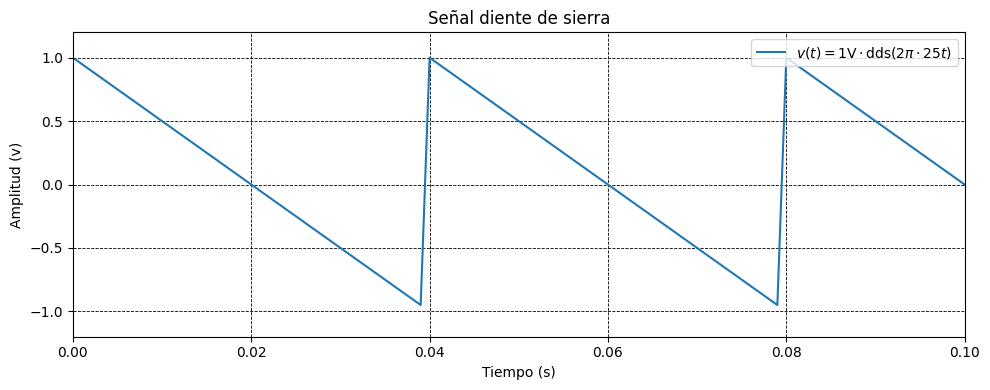

In [109]:
x1,tt = pds_dientedesierra(N, fs, Amax = 1, freq=25, dc = 0, phase = 0)

fig, ax = plt.subplots(figsize=(10, 4))

ax.grid(True, color="#000000FF", linewidth=0.6, linestyle="--")
ax.set_axisbelow(True)


ax.set_xlim(0, (1 / 50) * 5)
ax.set_ylim(-1.2, 1.2)

ax.plot(tt, x1, linewidth=1.5, label=r"$v(t) = 1\mathrm{V} \cdot \mathrm{dds}(2\pi \cdot 25t)$")

ax.legend(loc="upper right", fontsize=10)
ax.set_title("Señal diente de sierra", fontsize=12)
ax.set_xlabel("Tiempo (s)", fontsize=10)
ax.set_ylabel("Amplitud (v)", fontsize=10)


plt.tight_layout()
plt.show()

Vemos que es "poco ideal" la subida de la diente de sierra. Por un fenomeno similar al de la senoidal necesitamos mas puntos por ciclo para que esa subida tenga mas pendiente y se acerque a lo ideal.

### Experimentos con ff y fs

Experimentos hechos en clase:

1. ff = 500 Hz
2. ff = 999 Hz
3. ff = 1001 Hz
4. ff = 2001 Hz

### Experimento 1

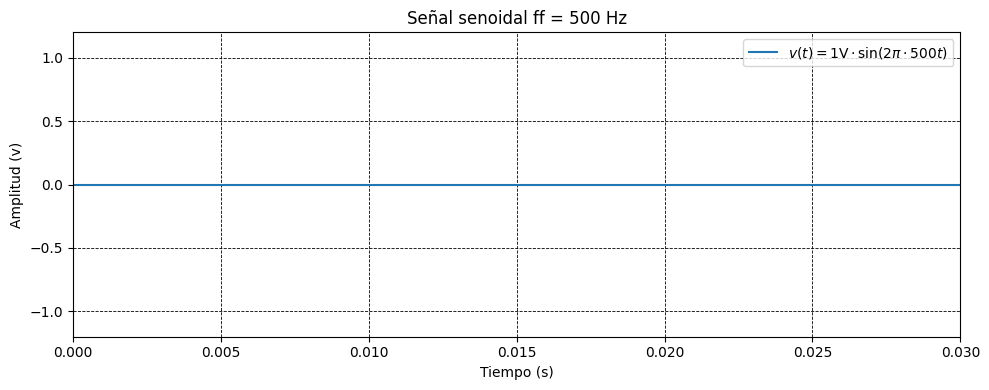

In [110]:
x1,tt = pds_sen(N, fs, Amax = 1, freq=500, dc = 0, phase = 0)

fig, ax = plt.subplots(figsize=(10, 4))

ax.grid(True, color="#000000FF", linewidth=0.6, linestyle="--")
ax.set_axisbelow(True)


ax.set_xlim(0, (1 / 100) * 3)
ax.set_ylim(-1.2, 1.2)

ax.plot(tt, x1, linewidth=1.5, label=r"$v(t) = 1\mathrm{V} \cdot \mathrm{sin}(2\pi \cdot 500t)$")

ax.legend(loc="upper right", fontsize=10)
ax.set_title("Señal senoidal ff = 500 Hz", fontsize=12)
ax.set_xlabel("Tiempo (s)", fontsize=10)
ax.set_ylabel("Amplitud (v)", fontsize=10)


plt.tight_layout()
plt.show()

Con una ff de 500 Hz tenemos el caso critico de fs = 2*ff. Tenemos 2 puntos por ciclo. Como la senoidal no esta desfasada los puntos estan en 0 y en pi, dando siempre 0 la interpolacion.

Con una senoidal desfasada:

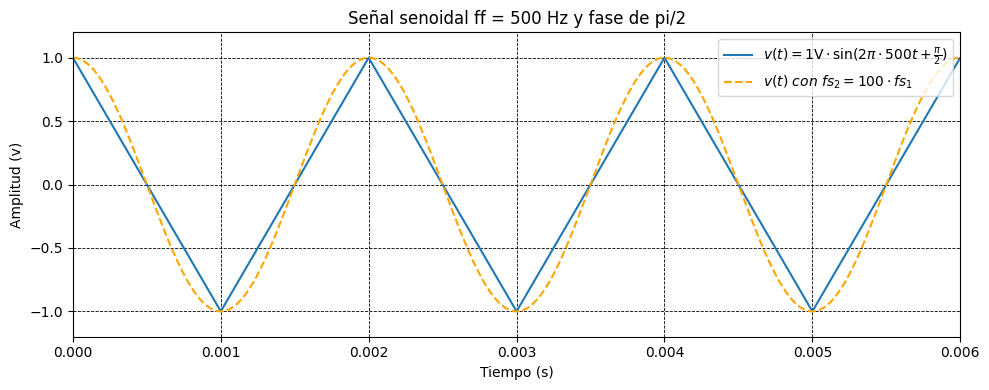

In [111]:
x1, tt = pds_sen(N, fs, Amax=1, freq=500, dc=0, phase=np.pi / 2)
x2, tt2 = pds_sen(N, fs*100, Amax=1, freq=500, dc=0, phase=np.pi / 2)

fig, ax = plt.subplots(figsize=(10, 4))

ax.grid(True, color="#000000FF", linewidth=0.6, linestyle="--")
ax.set_axisbelow(True)

ax.set_xlim(0, (1 / 500) * 3)
ax.set_ylim(-1.2, 1.2)

ax.plot(tt, x1, linewidth=1.5, label=r"$v(t) = 1\mathrm{V} \cdot \mathrm{sin}(2\pi \cdot 500t + \frac{\pi}{2})$")

ax.plot(tt2, x2, linewidth=1.5, linestyle="--", color="orange",
        label=r"$v(t)\ con\ fs_2=100 \cdot fs_1$")

ax.legend(loc="upper right", fontsize=10)
ax.set_title("Señal senoidal ff = 500 Hz y fase de pi/2", fontsize=12)
ax.set_xlabel("Tiempo (s)", fontsize=10)
ax.set_ylabel("Amplitud (v)", fontsize=10)

plt.tight_layout()
plt.show()

Vemos que cuando la señal esta desfasada los puntos donde se toma el valor ahora son distintos de 0 y la interpolacion nos da una señal distinto de 0.

En este caso particular la señal azul toma los valores maximos de la senoidal original (señal naranja punteada).

### Experimento 2

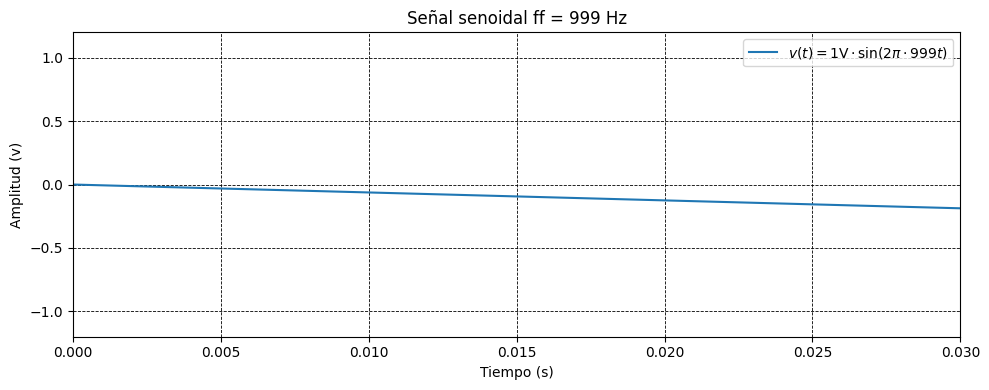

In [112]:
x1,tt = pds_sen(N, fs, Amax = 1, freq=999, dc = 0, phase = 0)

fig, ax = plt.subplots(figsize=(10, 4))

ax.grid(True, color="#000000FF", linewidth=0.6, linestyle="--")
ax.set_axisbelow(True)


ax.set_xlim(0, (1 / 100) * 3)
ax.set_ylim(-1.2, 1.2)

ax.plot(tt, x1, linewidth=1.5, label=r"$v(t) = 1\mathrm{V} \cdot \mathrm{sin}(2\pi \cdot 999t)$")

ax.legend(loc="upper right", fontsize=10)
ax.set_title("Señal senoidal ff = 999 Hz", fontsize=12)
ax.set_xlabel("Tiempo (s)", fontsize=10)
ax.set_ylabel("Amplitud (v)", fontsize=10)


plt.tight_layout()
plt.show()

A primera vista vemos una señal deformada, pero a diferencia de antes no es una constante en 0. Si aumentamos el rango del eje X:

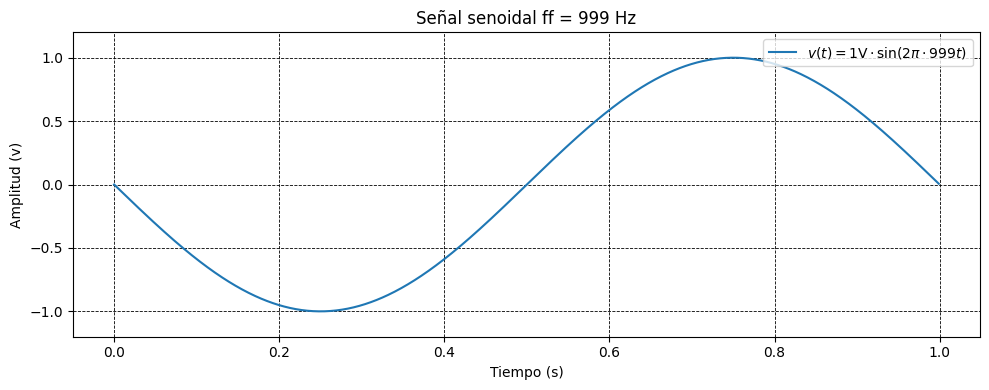

In [113]:
x1,tt = pds_sen(N, fs, Amax = 1, freq=999, dc = 0, phase = 0)

fig, ax = plt.subplots(figsize=(10, 4))

ax.grid(True, color="#000000FF", linewidth=0.6, linestyle="--")
ax.set_axisbelow(True)


#ax.set_xlim(0, (1 / 100) * 3)
ax.set_ylim(-1.2, 1.2)

ax.plot(tt, x1, linewidth=1.5, label=r"$v(t) = 1\mathrm{V} \cdot \mathrm{sin}(2\pi \cdot 999t)$")

ax.legend(loc="upper right", fontsize=10)
ax.set_title("Señal senoidal ff = 999 Hz", fontsize=12)
ax.set_xlabel("Tiempo (s)", fontsize=10)
ax.set_ylabel("Amplitud (v)", fontsize=10)


plt.tight_layout()
plt.show()

Notamos que tenemos una senoidal (negada) de 1 Hz. Esto se debe al efecto de aliasing. La senoidal original que esta en +999 Hz positiva y -999Hz negativa se duplica en +1999Hz positiva y +1Hz negativa. Sin un filtro anti-aliasing no podemos diferenciar estas señales.

### Experimento 3

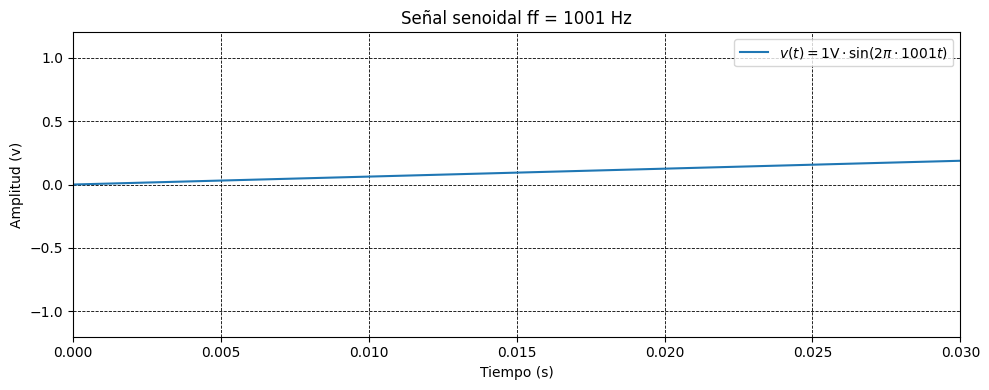

In [114]:
x1,tt = pds_sen(N, fs, Amax = 1, freq=1001, dc = 0, phase = 0)

fig, ax = plt.subplots(figsize=(10, 4))

ax.grid(True, color="#000000FF", linewidth=0.6, linestyle="--")
ax.set_axisbelow(True)


ax.set_xlim(0, (1 / 100) * 3)
ax.set_ylim(-1.2, 1.2)

ax.plot(tt, x1, linewidth=1.5, label=r"$v(t) = 1\mathrm{V} \cdot \mathrm{sin}(2\pi \cdot 1001t)$")

ax.legend(loc="upper right", fontsize=10)
ax.set_title("Señal senoidal ff = 1001 Hz", fontsize=12)
ax.set_xlabel("Tiempo (s)", fontsize=10)
ax.set_ylabel("Amplitud (v)", fontsize=10)


plt.tight_layout()
plt.show()

Vemos un efecto parecido al anterior. Si agrandamos el eje X:

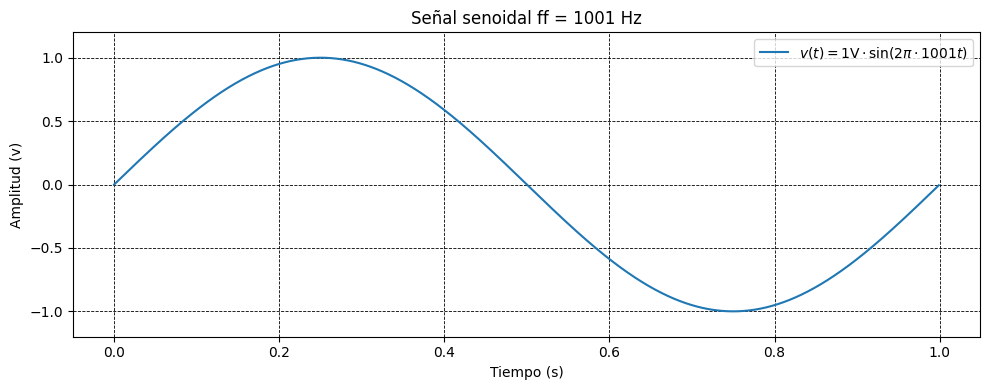

In [115]:
x1,tt = pds_sen(N, fs, Amax = 1, freq=1001, dc = 0, phase = 0)

fig, ax = plt.subplots(figsize=(10, 4))

ax.grid(True, color="#000000FF", linewidth=0.6, linestyle="--")
ax.set_axisbelow(True)


#ax.set_xlim(0, (1 / 100) * 3)
ax.set_ylim(-1.2, 1.2)

ax.plot(tt, x1, linewidth=1.5, label=r"$v(t) = 1\mathrm{V} \cdot \mathrm{sin}(2\pi \cdot 1001t)$")

ax.legend(loc="upper right", fontsize=10)
ax.set_title("Señal senoidal ff = 1001 Hz", fontsize=12)
ax.set_xlabel("Tiempo (s)", fontsize=10)
ax.set_ylabel("Amplitud (v)", fontsize=10)


plt.tight_layout()
plt.show()

Otra vez tenemos un efecto de aliasing. La diferencia es que ahora en f=1Hz tenemos la parte de "fase positiva" del espectro de la senoidal.

### Experimento 4

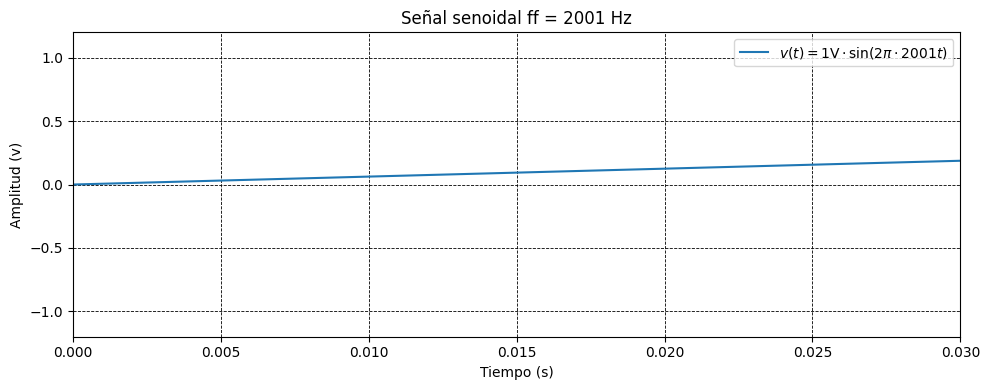

In [116]:
x1,tt = pds_sen(N, fs, Amax = 1, freq=2001, dc = 0, phase = 0)

fig, ax = plt.subplots(figsize=(10, 4))

ax.grid(True, color="#000000FF", linewidth=0.6, linestyle="--")
ax.set_axisbelow(True)


ax.set_xlim(0, (1 / 100) * 3)
ax.set_ylim(-1.2, 1.2)

ax.plot(tt, x1, linewidth=1.5, label=r"$v(t) = 1\mathrm{V} \cdot \mathrm{sin}(2\pi \cdot 2001t)$")

ax.legend(loc="upper right", fontsize=10)
ax.set_title("Señal senoidal ff = 2001 Hz", fontsize=12)
ax.set_xlabel("Tiempo (s)", fontsize=10)
ax.set_ylabel("Amplitud (v)", fontsize=10)


plt.tight_layout()
plt.show()

Volvemos a agrandar el eje X:

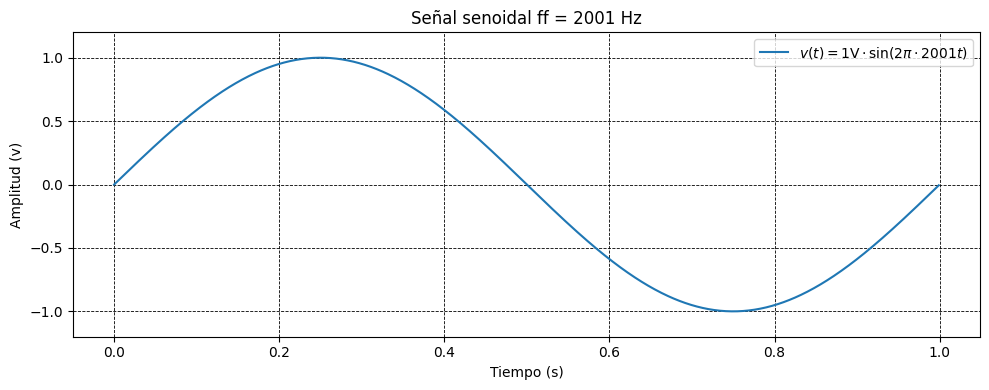

In [117]:
x1,tt = pds_sen(N, fs, Amax = 1, freq=2001, dc = 0, phase = 0)

fig, ax = plt.subplots(figsize=(10, 4))

ax.grid(True, color="#000000FF", linewidth=0.6, linestyle="--")
ax.set_axisbelow(True)


#ax.set_xlim(0, (1 / 100) * 3)
ax.set_ylim(-1.2, 1.2)

ax.plot(tt, x1, linewidth=1.5, label=r"$v(t) = 1\mathrm{V} \cdot \mathrm{sin}(2\pi \cdot 2001t)$")

ax.legend(loc="upper right", fontsize=10)
ax.set_title("Señal senoidal ff = 2001 Hz", fontsize=12)
ax.set_xlabel("Tiempo (s)", fontsize=10)
ax.set_ylabel("Amplitud (v)", fontsize=10)


plt.tight_layout()
plt.show()

Volvemos a tener otra vez el efecto de aliasing.

### Generador de ruido AWGN

En ruido AWGN, la potencia de ruido es igual a la varianza (con resistencia normalizada).

In [118]:
def pds_awgn(N, fs, potencia_W):
    tt = np.arange(start = 0, step = 1/fs, stop = N*(1/fs))
    desvio_std = sqrt(potencia_W)
    media = 0
    xx = np.random.normal(loc=media, scale=desvio_std, size=N)
    return xx, tt

Graficos con diferentes potencias de ruido:

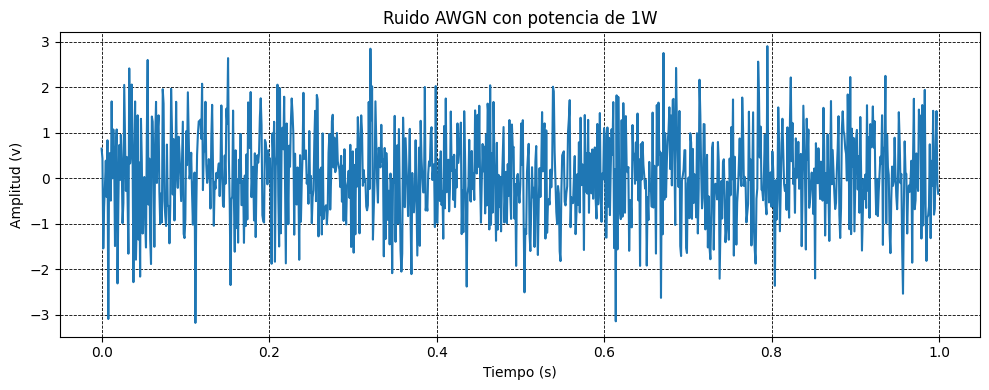

In [119]:
potencia = 1

x1,tt = pds_awgn(N, fs, potencia)

fig, ax = plt.subplots(figsize=(10, 4))

ax.grid(True, color="#000000FF", linewidth=0.6, linestyle="--")
ax.set_axisbelow(True)

ax.plot(tt, x1, linewidth=1.5)

ax.set_title(f"Ruido AWGN con potencia de {potencia}W", fontsize=12)
ax.set_xlabel("Tiempo (s)", fontsize=10)
ax.set_ylabel("Amplitud (v)", fontsize=10)


plt.tight_layout()
plt.show()

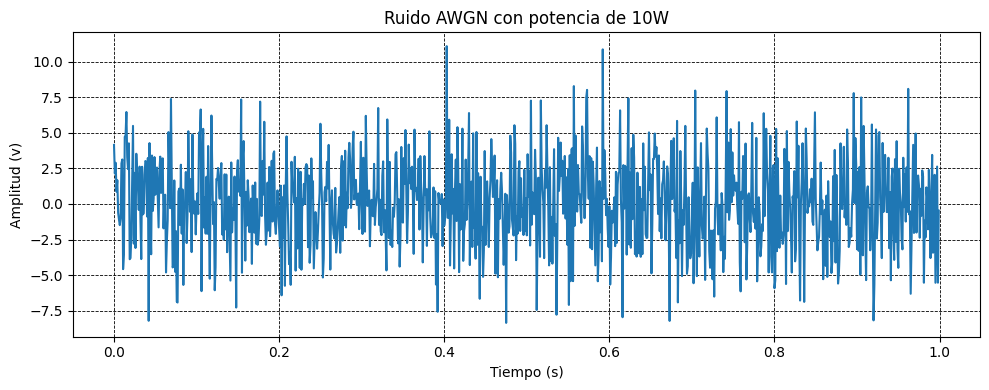

In [120]:
potencia = 10

x1,tt = pds_awgn(N, fs, potencia)

fig, ax = plt.subplots(figsize=(10, 4))

ax.grid(True, color="#000000FF", linewidth=0.6, linestyle="--")
ax.set_axisbelow(True)

ax.plot(tt, x1, linewidth=1.5)

ax.set_title(f"Ruido AWGN con potencia de {potencia}W", fontsize=12)
ax.set_xlabel("Tiempo (s)", fontsize=10)
ax.set_ylabel("Amplitud (v)", fontsize=10)


plt.tight_layout()
plt.show()

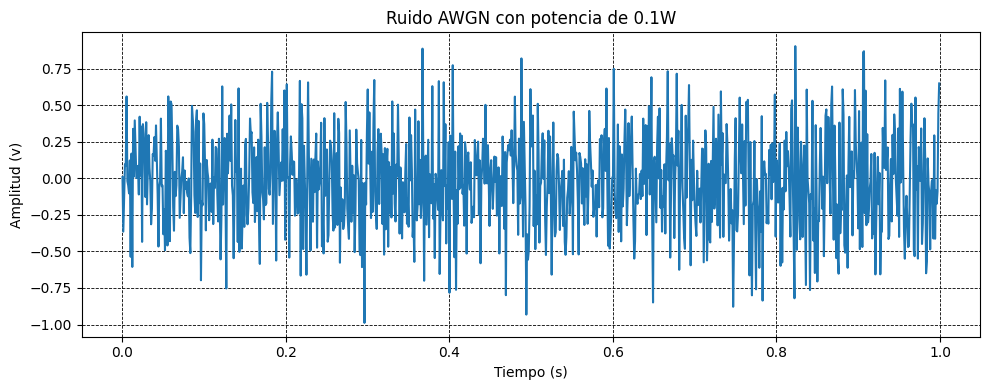

In [121]:
potencia = 0.1

x1,tt = pds_awgn(N, fs, potencia)

fig, ax = plt.subplots(figsize=(10, 4))

ax.grid(True, color="#000000FF", linewidth=0.6, linestyle="--")
ax.set_axisbelow(True)

ax.plot(tt, x1, linewidth=1.5)

ax.set_title(f"Ruido AWGN con potencia de {potencia}W", fontsize=12)
ax.set_xlabel("Tiempo (s)", fontsize=10)
ax.set_ylabel("Amplitud (v)", fontsize=10)


plt.tight_layout()
plt.show()

Vemos que a medida de que es mayor la potencia tenemos picos de mayor amplitud, pero que no escala linealmente la potencia con la amplitud de los picos. Tiene sentido ya que la potencia es la tension al cuadrado.

### Le agregamos al generador de senoidales un parametro de SNR

Teniendo como dato el SNR, y los datos de la señal, calculamos la potencia de ruido en dB, la pasamos a veces y usamos eso en la funcion de *pds_awgn*.

Sumamos el ruido a la señal ya que por definicion es aditivo.

In [122]:
def pds_sen_ruidosa(nn = 1000, fs = 1000, freq = 1, Amax = sqrt(2), dc = 0, phase = 0, SNR_db = "inf"):
    tt = np.arange(start = 0, step = 1/fs, stop = nn*(1/fs))
    x1 = dc + Amax * np.sin(2*np.pi * freq * tt + phase)

    if SNR_db != "inf" and (type(SNR_db) == float or type(SNR_db) == int):
        pot_senal = 10*np.log10((Amax**2) / 2)
        pot_ruido = pot_senal - SNR_db
        x2, tt = pds_awgn(nn, fs, potencia_W = 10**(pot_ruido/10))
        xx = x1 + x2
    else:
        xx = x1

    return xx, tt

Graficamos la senoidal ruidosa:

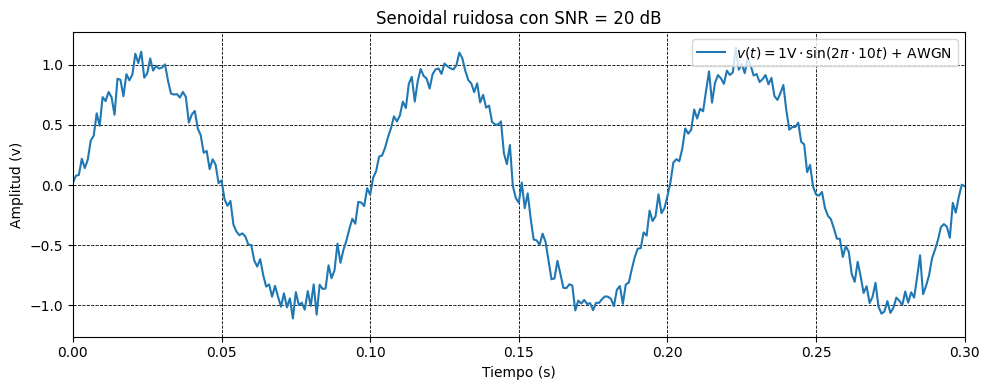

In [134]:
xx,tt = pds_sen_ruidosa(N, fs, freq = 10, Amax=1, SNR_db = 20)

fig, ax = plt.subplots(figsize=(10, 4))

ax.grid(True, color="#000000FF", linewidth=0.6, linestyle="--")
ax.set_axisbelow(True)

ax.set_xlim(0, (1 / 10) * 3)

ax.plot(tt, xx, linewidth=1.5, label=r"$v(t) = 1\mathrm{V} \cdot \mathrm{sin}(2\pi \cdot 10t)$ + AWGN")

ax.set_title(f"Senoidal ruidosa con SNR = 20 dB", fontsize=12)
ax.set_xlabel("Tiempo (s)", fontsize=10)
ax.set_ylabel("Amplitud (v)", fontsize=10)

ax.legend(loc="upper right", fontsize=10)


plt.tight_layout()
plt.show()